### A MNIST-like fashion product database

In this, we classify the images into respective classes given in the dataset. We use a Neural Net and a Deep Neural Net in Keras to solve this and check the accuracy scores.

### Load tensorflow

In [0]:
import tensorflow as tf
tf.set_random_seed(42)

In [2]:
tf.__version__

'1.14.0'

### Collect Data

In [3]:
import keras

Using TensorFlow backend.


In [4]:
(train_X, train_Y), (test_X, test_Y) = keras.datasets.fashion_mnist.load_data()

4423680/4422102 [==============================] - 1s 0us/step


In [5]:
print(test_Y[0:5])

[9 2 1 1 6]


In [6]:
print(train_Y[0:5])

[9 0 0 3 0]


### Visualize the data

Plot first 10 images in the triaining set and their labels.

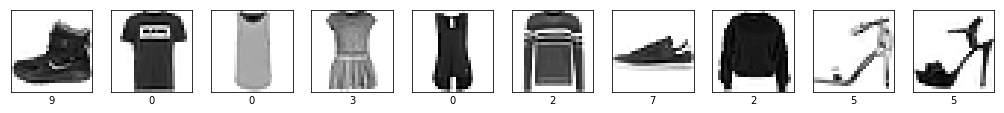

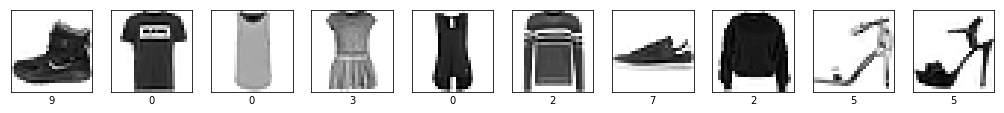

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline 
fig = plt.figure(figsize=(50,50))
for i in range(10):
  plt.subplot(28,28,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(train_X[i], cmap=plt.cm.binary)
  plt.xlabel(train_Y[i])
fig

### Convert both training and testing labels into one-hot vectors.

**Hint:** check **tf.keras.utils.to_categorical()**

In [0]:
trainY= tf.keras.utils.to_categorical(trainY)
testY= tf.keras.utils.to_categorical(testY)

In [9]:
print(train_Y.shape)
print('First 5 examples now are: ', train_Y[0:5])

(60000, 10)
First 5 examples now are:  [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [0]:
x_train=train_X.reshape(train_X.shape[0],28,28,1).astype('float32')
x_test=test_X.reshape(test_X.shape[0],28,28,1).astype('float32')

In [0]:
x_train/=255
x_test/=255

### Build a neural Network with a cross entropy loss function and sgd optimizer in Keras. The output layer with 10 neurons as we have 10 classes.

In [0]:
from keras.models import Sequential
from keras.layers.convolutional import Conv2D,MaxPooling2D
from keras.layers.core import Dense,Dropout,Activation,Flatten

In [13]:
model=Sequential()
model.add(Conv2D(32,(3,3),border_mode='valid',input_shape=(28,28,1),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.compile(loss='categorical_crossentropy',optimizer='sgd',metrics=['accuracy'])

W0728 17:57:00.353547 140277413017472 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:74: The name tf.get_default_graph is deprecated. Please use tf.compat.v1.get_default_graph instead.

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:2: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3), input_shape=(28, 28, 1..., activation="relu", padding="valid")`
  
W0728 17:57:00.363252 140277413017472 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:517: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.

W0728 17:57:00.373303 140277413017472 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:4138: The name tf.random_uniform is deprecated. Please use tf.random.uniform instead.

W0728 17:57:00.422933 140277413017472 deprecation_wrapper.py:119] From /us

### Execute the model using model.fit()

In [14]:
model.fit(x_train,trainY,batch_size=200,nb_epoch=12,verbose=1,validation_data=(x_test,testY))

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  """Entry point for launching an IPython kernel.
W0728 17:57:21.295282 140277413017472 deprecation.py:323] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/math_grad.py:1250: add_dispatch_support.<locals>.wrapper (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
W0728 17:57:21.362480 140277413017472 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:986: The name tf.assign_add is deprecated. Please use tf.compat.v1.assign_add instead.



Train on 60000 samples, validate on 10000 samples
Epoch 1/12
60000/60000 [==============================] - 30s 494us/step - loss: 1.2427 - acc: 0.6256 - val_loss: 0.7771 - val_acc: 0.7205
Epoch 2/12
60000/60000 [==============================] - 29s 482us/step - loss: 0.6398 - acc: 0.7779 - val_loss: 0.6035 - val_acc: 0.7830
Epoch 3/12
60000/60000 [==============================] - 29s 478us/step - loss: 0.5690 - acc: 0.7972 - val_loss: 0.5692 - val_acc: 0.7895
Epoch 4/12
60000/60000 [==============================] - 29s 483us/step - loss: 0.5342 - acc: 0.8095 - val_loss: 0.5817 - val_acc: 0.7953
Epoch 5/12
60000/60000 [==============================] - 29s 481us/step - loss: 0.5129 - acc: 0.8167 - val_loss: 0.5083 - val_acc: 0.8184
Epoch 6/12
60000/60000 [==============================] - 29s 483us/step - loss: 0.4918 - acc: 0.8249 - val_loss: 0.4930 - val_acc: 0.8251
Epoch 7/12
60000/60000 [==============================] - 29s 485us/step - loss: 0.4770 - acc: 0.8318 - val_loss: 0.

In [15]:
score=model.evaluate(x_test,testY)
score

10000/10000 [==============================] - 2s 212us/step


[0.4367933979034424, 0.8441]

### In the above Neural Network model add Batch Normalization layer after the input layer and repeat the steps.

In [16]:
model1 = tf.keras.models.Sequential()
model1.add(tf.keras.layers.BatchNormalization(input_shape=x_train.shape[1:]))
model1.add(tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='elu'))
model1.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2,2)))
model1.add(tf.keras.layers.Flatten())
model1.add(tf.keras.layers.Dense(256))
model1.add(tf.keras.layers.Activation('elu'))
model1.add(tf.keras.layers.Dropout(0.5))
model1.add(tf.keras.layers.Dense(10))
model1.add(tf.keras.layers.Activation('softmax'))
model1.compile(loss='categorical_crossentropy',optimizer='sgd',metrics=['accuracy'])

W0728 18:03:42.454818 140277413017472 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


### Execute the model

In [17]:
model1.fit(x_train,trainY,batch_size=200,nb_epoch=5,verbose=1,validation_data=(x_test,testY))

W0728 18:04:04.517089 140277413017472 training.py:593] The `nb_epoch` argument in `fit` has been renamed `epochs`.


Train on 60000 samples, validate on 10000 samples
Epoch 1/5
60000/60000 [==============================] - 50s 834us/sample - loss: 0.7645 - acc: 0.7325 - val_loss: 0.5668 - val_acc: 0.8004
Epoch 2/5
60000/60000 [==============================] - 50s 835us/sample - loss: 0.5201 - acc: 0.8176 - val_loss: 0.4734 - val_acc: 0.8327
Epoch 3/5
60000/60000 [==============================] - 50s 835us/sample - loss: 0.4671 - acc: 0.8365 - val_loss: 0.4289 - val_acc: 0.8461
Epoch 4/5
60000/60000 [==============================] - 51s 844us/sample - loss: 0.4357 - acc: 0.8480 - val_loss: 0.4192 - val_acc: 0.8487
Epoch 5/5
60000/60000 [==============================] - 51s 847us/sample - loss: 0.4102 - acc: 0.8570 - val_loss: 0.3934 - val_acc: 0.8590


In [18]:
score=model1.evaluate(x_test,testY)
score

10000/10000 [==============================] - 4s 381us/sample - loss: 0.3934 - acc: 0.8590


[0.3933825593709946, 0.859]

### Customize the learning rate to 0.001 in sgd optimizer and run the model

In [0]:
from keras import optimizers

In [0]:
model2 = tf.keras.models.Sequential()
model2.add(tf.keras.layers.BatchNormalization(input_shape=x_train.shape[1:]))
model2.add(tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='elu'))
model2.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2,2)))
model2.add(tf.keras.layers.Flatten())
model2.add(tf.keras.layers.Dense(256))
model2.add(tf.keras.layers.Activation('elu'))
model2.add(tf.keras.layers.Dropout(0.5))
model2.add(tf.keras.layers.Dense(10))
model2.add(tf.keras.layers.Activation('softmax'))
sgd = optimizers.SGD(lr=0.001)
model2.compile(loss='categorical_crossentropy',optimizer='sgd' ,metrics=['accuracy'])

In [21]:
model2.fit(x_train,trainY,batch_size=200,nb_epoch=5,verbose=1,validation_data=(x_test,testY))

W0728 18:12:02.120560 140277413017472 training.py:593] The `nb_epoch` argument in `fit` has been renamed `epochs`.


Train on 60000 samples, validate on 10000 samples
Epoch 1/5
60000/60000 [==============================] - 50s 832us/sample - loss: 0.7350 - acc: 0.7444 - val_loss: 0.5288 - val_acc: 0.8174
Epoch 2/5
60000/60000 [==============================] - 50s 838us/sample - loss: 0.5024 - acc: 0.8223 - val_loss: 0.4477 - val_acc: 0.8396
Epoch 3/5
60000/60000 [==============================] - 50s 838us/sample - loss: 0.4497 - acc: 0.8407 - val_loss: 0.4236 - val_acc: 0.8494
Epoch 4/5
60000/60000 [==============================] - 51s 842us/sample - loss: 0.4213 - acc: 0.8531 - val_loss: 0.3972 - val_acc: 0.8594
Epoch 5/5
60000/60000 [==============================] - 50s 841us/sample - loss: 0.3990 - acc: 0.8593 - val_loss: 0.3819 - val_acc: 0.8654


In [22]:
score=model2.evaluate(x_test,testY)
score

10000/10000 [==============================] - 4s 383us/sample - loss: 0.3819 - acc: 0.8654


[0.3818968868255615, 0.8654]

### Build the Neural Network model with 3 Dense layers with 100,100,10 neurons respectively in each layer. Use cross entropy loss function and singmoid as activation in the hidden layers and softmax as activation function in the output layer. Use sgd optimizer with learning rate 0.03.

In [23]:
model3=Sequential()
model3.add(Conv2D(32,(3,3),border_mode='valid',input_shape=(28,28,1),activation='relu'))
model3.add(MaxPooling2D(pool_size=(2,2)))
model3.add(Flatten())
model3.add(Dense(100,activation='sigmoid'))
model3.add(Dense(100,activation='sigmoid'))
model3.add(Dense(10,activation='softmax'))
sgd = optimizers.SGD(lr=0.03)
model3.compile(loss='categorical_crossentropy',optimizer='sgd',metrics=['accuracy'])

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:2: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3), input_shape=(28, 28, 1..., activation="relu", padding="valid")`
  


### Run the model

In [24]:
model3.fit(x_train,trainY,batch_size=200,nb_epoch=5,verbose=1,validation_data=(x_test,testY))

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  """Entry point for launching an IPython kernel.


Train on 60000 samples, validate on 10000 samples
Epoch 1/5
60000/60000 [==============================] - 27s 453us/step - loss: 2.3103 - acc: 0.1344 - val_loss: 2.2890 - val_acc: 0.1012
Epoch 2/5
60000/60000 [==============================] - 27s 445us/step - loss: 2.2762 - acc: 0.2790 - val_loss: 2.2586 - val_acc: 0.3431
Epoch 3/5
60000/60000 [==============================] - 27s 448us/step - loss: 2.2241 - acc: 0.4590 - val_loss: 2.1768 - val_acc: 0.4501
Epoch 4/5
60000/60000 [==============================] - 27s 447us/step - loss: 2.0884 - acc: 0.5370 - val_loss: 1.9760 - val_acc: 0.5365
Epoch 5/5
60000/60000 [==============================] - 27s 447us/step - loss: 1.8299 - acc: 0.5437 - val_loss: 1.6851 - val_acc: 0.5340


In [25]:
score=model3.evaluate(x_test,testY)
score

10000/10000 [==============================] - 2s 209us/step


[1.6850548095703124, 0.534]

## Review model

In [26]:
The validation accuracy does not improve after few epochs and the validation loss is increasing after few epochs. This confirms that the model is overfitted. 
After adding more Dense layers, the validation accuracy and validation loss are much better.

SyntaxError: ignored